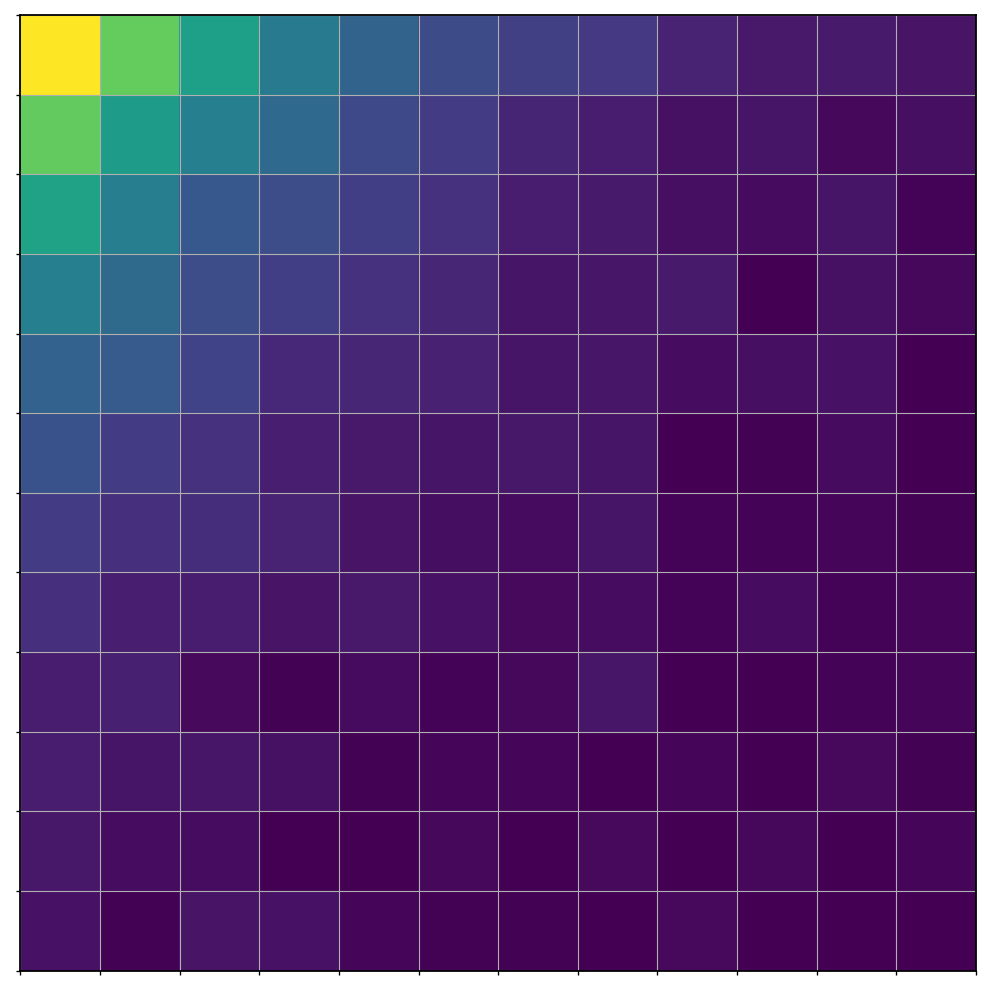

In [ ]:
# Top-left focused “VPM-style” grid
import numpy as np
import matplotlib.pyplot as plt

# --- tweakables ---
tiles_per_side = 12    # grid tiles per side (e.g., 24x24)
px_per_tile    = 16    # pixels per tile (controls total resolution)
decay_alpha    = 0.28  # larger => faster fade away from top-left
noise_level    = 0.02  # set to 0.0 to remove organic noise
rng_seed       = 7

# Build a tile intensity map that decays from the top-left corner
rng = np.random.default_rng(rng_seed)
y, x = np.meshgrid(np.arange(tiles_per_side),
                   np.arange(tiles_per_side),
                   indexing="ij")
base = np.exp(-decay_alpha * (x + y))              # 0..1, brightest at (0,0)
if noise_level > 0:
    base = np.clip(base + rng.normal(0, noise_level, base.shape), 0, 1)

# Upsample each tile to px_per_tile x px_per_tile pixels (nearest = crisp grid look)
img = np.kron(base, np.ones((px_per_tile, px_per_tile), dtype=float))

# Render (single plot, default colormap)
fig, ax = plt.subplots(figsize=(6, 6), dpi=160)
ax.imshow(img, interpolation="nearest")

# Draw tile gridlines without changing colors
ax.set_xticks(np.arange(-0.5, img.shape[1], px_per_tile), minor=True)
ax.set_yticks(np.arange(-0.5, img.shape[0], px_per_tile), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.5)

# Hide ticks/labels for a clean, poster-friendly image
ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout(pad=0)
plt.show()

# Optional: save to file
plt.savefig("zeromodel_top_left_grid.png", bbox_inches="tight", pad_inches=0, dpi=160)
